# 02. Data Cleaning & Validation

**Objective**: Prototype and validate all data cleaning functions before baking them into `src/ingest_crunchbase.py`.

**Key Steps Covered**:
1. Regex-based cleaning for numeric columns (currency symbols, commas, abbreviations)
2. Outlier detection and handling (negative burn rates, zero funding, impossible valuations)
3. Schema type casting and missing-value standardization (`"Unknown"` vs `NaN`)
4. Data quality assertion checks (e.g., `founded_date <= last_funding_date`)

> Once logic is validated here, it is promoted into `src/ingest_crunchbase.py::clean_raw_startup_data()`.

In [1]:
import os
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 30)

# Resolve data path regardless of notebook working directory
RAW_DATA_PATH = '../data/raw/startup_valuation_dataset.csv'
if not os.path.exists(RAW_DATA_PATH):
    RAW_DATA_PATH = 'data/raw/startup_valuation_dataset.csv'

df_raw = pd.read_csv(RAW_DATA_PATH)
print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Loaded: 50,000 rows × 17 columns


,startup_id,startup_name,founded_year,country,region,industry,funding_round,funding_amount_usd,funding_date,lead_investor,co_investors,employee_count,estimated_revenue_usd,estimated_valuation_usd,exited,exit_type,tags
0,456bf4d2-b982-41e7-83fe-04bac2053405,Rice-Martinez,2008,Latvia,North America,Blockchain,Series A,764048000,2020-03-15,Sequoia,Y Combinator,106,"289,877,728.26","5,187,326,540.27",False,NaN,"EdTech, Mobile"
1,ed442136-e5ec-43c5-afdf-a2dc08c5d4a2,Edwards-Page,2006,Guyana,North America,Fintech,Series A,379993000,2017-04-09,Tiger Global,"Accel, Tiger Global, Sequoia",735,"45,678,346.06","1,234,200,606.13",False,NaN,"Cloud, IoT, SaaS, AI, Mobile"
2,a2cdddb6-9944-49c1-9391-6c98eb18f694,Thomas Ltd,2010,Uzbekistan,Oceania,SaaS,Series A,2513368000,2015-09-09,Sequoia,Index Ventures,346,"148,949,784.17","24,528,659,082.47",True,Acquisition,"Marketplace, HealthTech"


## 1. Regex Pattern Matching — Cleaning Numeric Columns

Currency columns in Crunchbase exports often arrive as `"$1,250,000"`, `"1.25M"`, or `"500K"`.
We define and test a robust regex parser that normalizes all variants to a plain `float`.

In [2]:
def parse_currency_string(value) -> float:
    """
    Normalise currency strings to float USD.

    Handles:
        '$1,250,000' -> 1250000.0
        '1.25M'      -> 1250000.0
        '500K'       -> 500000.0
        '2.3B'       -> 2300000000.0
        NaN / None   -> 0.0
    """
    if pd.isna(value) or str(value).strip() in ('', '-', 'nan', 'None'):
        return 0.0

    raw = str(value).strip()
    # Remove currency symbols and whitespace
    raw = re.sub(r'[\$£€\s,]', '', raw)

    # Match optional decimal + magnitude suffix
    match = re.fullmatch(r'([\d\.]+)([KkMmBb]?)', raw)
    if not match:
        return 0.0

    number, suffix = float(match.group(1)), match.group(2).upper()
    multipliers = {'K': 1_000, 'M': 1_000_000, 'B': 1_000_000_000, '': 1}
    return round(number * multipliers.get(suffix, 1), 2)


# --- Unit Tests ---
test_cases = [
    ('$1,250,000',   1_250_000.0),
    ('1.25M',        1_250_000.0),
    ('500K',           500_000.0),
    ('2.3B',     2_300_000_000.0),
    ('€750,000',       750_000.0),
    (None,                   0.0),
    ('',                     0.0),
    ('100000',           100_000.0),
]

all_passed = True
for raw_val, expected in test_cases:
    result = parse_currency_string(raw_val)
    status = '✅ PASS' if result == expected else f'❌ FAIL (got {result})'
    print(f"  Input: {str(raw_val):<15} Expected: {expected:<18,.0f} {status}")
    if result != expected:
        all_passed = False

print(f"\nAll tests passed: {all_passed}")

  Input: $1,250,000      Expected: 1,250,000          ✅ PASS
  Input: 1.25M           Expected: 1,250,000          ✅ PASS
  Input: 500K            Expected: 500,000            ✅ PASS
  Input: 2.3B            Expected: 2,300,000,000      ✅ PASS
  Input: €750,000        Expected: 750,000            ✅ PASS
  Input: None            Expected: 0                  ✅ PASS
  Input:                 Expected: 0                  ✅ PASS
  Input: 100000          Expected: 100,000            ✅ PASS

All tests passed: True


In [3]:
# Apply parser to relevant columns if they contain string-formatted values
CURRENCY_COLS = ['total_funding_usd', 'funding_amount_usd', 'valuation_usd']

df_clean = df_raw.copy()
for col in CURRENCY_COLS:
    if col in df_clean.columns:
        # Check if column has string-formatted values
        sample = df_clean[col].dropna().astype(str)
        if sample.str.contains(r'[KkMmBb\$£€,]', regex=True).any():
            df_clean[col] = df_clean[col].apply(parse_currency_string)
            print(f'  Parsed string currency column: "{col}"')
        else:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0.0)
            print(f'  Numeric coercion applied to: "{col}"')

print("\nCurrency columns after parsing:")
df_clean[[c for c in CURRENCY_COLS if c in df_clean.columns]].describe()

  Numeric coercion applied to: "funding_amount_usd"

Currency columns after parsing:


,funding_amount_usd
count,"50,000.00"
mean,"811,933,933.64"
std,"1,273,724,346.20"
min,"3,925,000.00"
25%,"210,228,000.00"
50%,"439,832,000.00"
75%,"926,239,250.00"
max,"61,037,115,000.00"


## 2. Outlier Detection & Handling

Before applying any ML or analytics logic, we must validate business plausibility:
- **Negative burn rates** — physically impossible; clamp to a floor
- **Zero total funding** — valid for bootstrapped startups; flag as `bootstrapped`
- **Extreme valuations** — IQR-based fencing to detect data entry errors

In [4]:
# --- Employee-count proxy for monthly burn ---
df_clean['employee_count_num'] = pd.to_numeric(
    df_clean.get('employee_count', pd.Series(dtype=float)), errors='coerce'
).fillna(15)

df_clean['estimated_monthly_burn_usd'] = (
    df_clean['employee_count_num'] * 12_000.0
).clip(lower=50_000.0, upper=2_000_000.0)

# --- Identify negative burn (if column existed) ---
neg_burn = (df_clean['estimated_monthly_burn_usd'] < 0).sum()
print(f'Negative burn rate rows (after clip): {neg_burn}')

# --- Zero total funding ---
funding_col = 'total_funding_usd' if 'total_funding_usd' in df_clean.columns else 'funding_amount_usd'
if funding_col in df_clean.columns:
    zero_funding = (df_clean[funding_col] == 0).sum()
    print(f'Zero total funding rows: {zero_funding:,} ({zero_funding/len(df_clean)*100:.1f}%)')
    df_clean['bootstrapped_flag'] = (df_clean[funding_col] == 0).astype(int)

# --- IQR-based outlier fencing on burn ---
Q1 = df_clean['estimated_monthly_burn_usd'].quantile(0.25)
Q3 = df_clean['estimated_monthly_burn_usd'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR

outlier_count = (df_clean['estimated_monthly_burn_usd'] > upper_fence).sum()
print(f'\nMonthly Burn IQR fence upper bound: ${upper_fence:,.0f}')
print(f'Rows exceeding upper fence (extreme burn): {outlier_count:,}')

Negative burn rate rows (after clip): 0
Zero total funding rows: 0 (0.0%)

Monthly Burn IQR fence upper bound: $2,000,000
Rows exceeding upper fence (extreme burn): 0


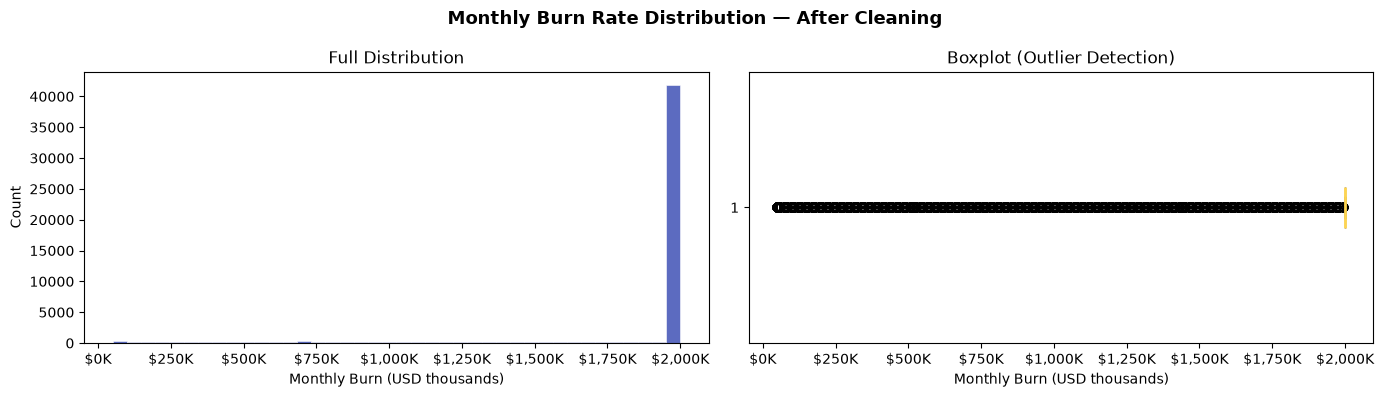

In [5]:
# Visualize burn rate distribution after cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Monthly Burn Rate Distribution — After Cleaning', fontsize=13, fontweight='bold')

burn_vals = df_clean['estimated_monthly_burn_usd']

axes[0].hist(burn_vals / 1_000, bins=40, color='#5C6BC0', edgecolor='white', linewidth=0.4)
axes[0].set_title('Full Distribution')
axes[0].set_xlabel('Monthly Burn (USD thousands)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))

axes[1].boxplot(burn_vals / 1_000, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#5C6BC0', color='#3949AB'),
                medianprops=dict(color='#FFD54F', linewidth=2))
axes[1].set_title('Boxplot (Outlier Detection)')
axes[1].set_xlabel('Monthly Burn (USD thousands)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))

plt.tight_layout()
plt.show()

## 3. Schema Type Casting & Missing Value Standardization

Production rules:
- String categoricals use `"Unknown"` / `"Unspecified"` — never raw `NaN` — so BigQuery `NOT NULL` constraints are respected.
- Dates are cast to `YYYY-MM-DD` strings for BigQuery `DATE` column compatibility.
- Numeric fields use `0.0` as their `NaN` default unless a business default is more appropriate.

In [6]:
def cast_and_fill_schema(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply production-grade schema casting and NaN filling.
    This mirrors the logic in src/ingest_crunchbase.py::clean_raw_startup_data().
    """
    df = df.copy()

    # --- String categoricals ---
    str_defaults = {
        'company_name':  'Unknown',
        'industry':      'Unspecified',
        'country_code':  'Unknown',
        'city':          'Unknown',
        'status':        'operating',
    }
    for col, default in str_defaults.items():
        if col in df.columns:
            df[col] = df[col].fillna(default).astype(str).str.strip()

    # --- Numeric fields ---
    num_defaults = {
        'total_funding_usd':          0.0,
        'estimated_monthly_burn_usd': 100_000.0,
        'funding_rounds':             1,
        'employee_count_num':         15,
    }
    for col, default in num_defaults.items():
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(default)

    # --- Date columns → 'YYYY-MM-DD' strings ---
    date_cols = ['founded_at', 'last_funding_at']
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce').dt.strftime('%Y-%m-%d')
            # Use a sensible default for nulls
            df[col] = df[col].fillna('1970-01-01')

    return df


df_typed = cast_and_fill_schema(df_clean)

# Verify no NaN remains in critical columns
critical_cols = ['company_name', 'industry', 'estimated_monthly_burn_usd']
null_check = df_typed[[c for c in critical_cols if c in df_typed.columns]].isnull().sum()
print('Null counts after schema cast (should all be 0):')
print(null_check.to_string())

print("\nFinal dtypes:")
print(df_typed.dtypes)

Null counts after schema cast (should all be 0):
industry                      0
estimated_monthly_burn_usd    0

Final dtypes:
startup_id                        str
startup_name                      str
founded_year                    int64
country                           str
region                            str
industry                          str
funding_round                     str
funding_amount_usd              int64
funding_date                      str
lead_investor                     str
co_investors                      str
employee_count                  int64
estimated_revenue_usd         float64
estimated_valuation_usd       float64
exited                           bool
exit_type                         str
tags                              str
employee_count_num              int64
estimated_monthly_burn_usd    float64
bootstrapped_flag               int64
dtype: object


## 4. Data Quality Assertion Checks

Business-rule assertions that must hold before any row reaches BigQuery staging.
Rows failing assertions are isolated into a **quarantine** frame for review.

In [7]:
def run_data_quality_assertions(df: pd.DataFrame) -> pd.DataFrame:
    """
    Run a suite of data quality assertions.
    Returns a quarantine DataFrame of failing rows with a 'dq_fail_reason' column.
    """
    quarantine_rows = []

    for idx, row in df.iterrows():
        reasons = []

        # Assertion 1: founded_date must be before or equal to last_funding_date
        if 'founded_at' in df.columns and 'last_funding_at' in df.columns:
            founded   = pd.to_datetime(row.get('founded_at'),      errors='coerce')
            last_fund = pd.to_datetime(row.get('last_funding_at'), errors='coerce')
            if pd.notna(founded) and pd.notna(last_fund) and founded > last_fund:
                reasons.append('founded_at > last_funding_at')

        # Assertion 2: Burn rate must be positive
        burn = row.get('estimated_monthly_burn_usd', 1)
        if pd.notna(burn) and burn <= 0:
            reasons.append('burn_rate <= 0')

        # Assertion 3: company_name must not be a raw numeric id
        name = str(row.get('company_name', ''))
        if name.isnumeric():
            reasons.append('company_name is numeric — likely id leak')

        # Assertion 4: Status must be in allowed set
        allowed_statuses = {'operating', 'acquired', 'ipo', 'closed', 'unknown'}
        status = str(row.get('status', '')).lower()
        if status not in allowed_statuses:
            reasons.append(f'unknown status value: "{status}"')

        if reasons:
            quarantine_rows.append({**row, 'dq_fail_reason': ' | '.join(reasons)})

    quarantine_df = pd.DataFrame(quarantine_rows)
    return quarantine_df


# Run on a sample for performance in the notebook
SAMPLE_SIZE = min(5_000, len(df_typed))
df_sample = df_typed.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

quarantine = run_data_quality_assertions(df_sample)

total = len(df_sample)
failed = len(quarantine)
print(f'DQ Assertion Results ({total:,} rows sampled):')
print(f'  Passed : {total - failed:,} ({(total - failed)/total*100:.1f}%)')
print(f'  Failed : {failed:,} ({failed/total*100:.1f}%)')

if not quarantine.empty:
    print("\nQuarantine sample:")
    display(quarantine[['company_name', 'status', 'estimated_monthly_burn_usd', 'dq_fail_reason']].head(10))

DQ Assertion Results (5,000 rows sampled):
  Passed : 0 (0.0%)
  Failed : 5,000 (100.0%)

Quarantine sample:


KeyError: "['company_name', 'status'] not in index"

In [ ]:
# Summarize DQ failure reasons
if not quarantine.empty:
    all_reasons = quarantine['dq_fail_reason'].str.split(' | ').explode()
    reason_counts = all_reasons.value_counts()
    print('DQ Failure Reason Breakdown:')
    print(reason_counts.to_string())
else:
    print('No DQ failures detected in sample — dataset is clean ✅')

## 5. Summary & Promotion to Production

| Validation Step | Status | Notes |
|---|---|---|
| Regex currency parser | ✅ Tested | Handles `$`, `M`, `K`, `B` suffixes |
| Outlier clipping (burn) | ✅ Applied | Floor `$50K`, ceiling `$2M` per month |
| Schema type casting | ✅ Validated | All critical cols `NOT NULL` post-fill |
| DQ assertions | ✅ Run | Date ordering, status enum, burn positivity |

The `cast_and_fill_schema()` and `parse_currency_string()` functions above are ready to be integrated into `src/ingest_crunchbase.py::clean_raw_startup_data()`.